# Laboratorio 4 — Análisis de Datos GeoEspaciales
## Notebook 2: Índices espectrales y análisis temporal (Ejercicios 3 y 4)

Requiere haber corrido antes `01_conexion_y_descarga.ipynb` (los archivos `data/raw/<lago>/<fecha>_bandas.tif` y `<fecha>_cyano.tif` deben existir).

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from src.config import LAGOS, DATA_RAW, DATA_PROCESSED
from src.indices import calcular_ndvi_ndwi_desde_tif

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

### Ejercicio 3 — Cálculo de índices (NDVI, NDWI, cianobacteria) por lago y fecha

- NDVI y NDWI se calculan localmente a partir de B04/B08 y B03/B08 (`src/indices.py`).
- El índice de cianobacteria (chl-a en µg/L) ya viene calculado desde el script oficial de Sentinel Hub (banda 1 del archivo `_cyano.tif`; banda 2 = máscara de agua, banda 3 = FAI, banda 4 = dataMask).

In [2]:
def cargar_cyano(ruta_tif):
    with rasterio.open(ruta_tif) as src:
        chl = src.read(1)
        water_mask = src.read(2)
        fai = src.read(3)
        data_mask = src.read(4)
        perfil = src.profile
    chl = np.where(data_mask == 1, chl, np.nan)
    return chl, water_mask, fai, perfil


registros = []
raster_cache = {}  # (lago, fecha) -> dict con arrays, para el analisis espacial

for lago, info in LAGOS.items():
    for fecha in info["fechas"]:
        ruta_bandas = DATA_RAW / lago / f"{fecha}_bandas.tif"
        ruta_cyano = DATA_RAW / lago / f"{fecha}_cyano.tif"
        if not (ruta_bandas.exists() and ruta_cyano.exists()):
            print(f"Faltan datos para {lago} - {fecha}, se omite (corre el Notebook 1 primero).")
            continue

        ndvi, ndwi, _ = calcular_ndvi_ndwi_desde_tif(ruta_bandas)
        chl, water_mask, fai, _ = cargar_cyano(ruta_cyano)

        raster_cache[(lago, fecha)] = {
            "ndvi": ndvi, "ndwi": ndwi, "chl": chl, "water_mask": water_mask,
        }

        registros.append({
            "lago": lago,
            "fecha": fecha,
            "cyano_promedio": np.nanmean(chl),
            "cyano_max": np.nanmax(chl) if np.isfinite(chl).any() else np.nan,
            "cyano_p90": np.nanpercentile(chl, 90) if np.isfinite(chl).any() else np.nan,
            "pct_area_alta": float(np.nanmean(chl > 10) * 100) if np.isfinite(chl).any() else np.nan,
            "ndvi_promedio": np.nanmean(ndvi),
            "ndwi_promedio": np.nanmean(ndwi),
            "pct_pixeles_agua": float(np.nanmean(water_mask) * 100),
        })

df = pd.DataFrame(registros)
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values(["lago", "fecha"]).reset_index(drop=True)
df.to_csv(DATA_PROCESSED / "indices_por_lago_fecha.csv", index=False)
df

,lago,fecha,cyano_promedio,cyano_max,cyano_p90,pct_area_alta,ndvi_promedio,ndwi_promedio,pct_pixeles_agua
0,amatitlan,2025-01-28,4.434624,21.600559,4.750061,0.003911,0.464348,-0.432018,12.023724
1,amatitlan,2025-04-15,4.530496,21.943108,5.906035,0.079841,0.425680,-0.415643,11.885877
2,amatitlan,2025-04-28,5.733905,33.563240,8.984408,0.871733,0.426856,-0.414178,11.886203
3,amatitlan,2025-11-24,4.437471,95.581238,5.121861,0.204328,0.371055,-0.326614,11.972886
4,amatitlan,2026-01-08,6.327679,101.661842,7.711410,0.805253,0.534277,-0.482229,12.034152
5,amatitlan,2026-02-02,4.289955,14.016261,4.702783,0.000652,0.490492,-0.478907,11.799518
6,amatitlan,2026-02-07,4.309173,15.427299,4.737756,0.003259,0.300502,-0.295708,11.989833
7,amatitlan,2026-03-29,6.431487,42.200291,8.168883,0.913446,0.424218,-0.420861,12.023398
8,amatitlan,2026-04-13,6.738921,28.158697,8.635921,0.539986,0.454553,-0.428901,12.074561
9,amatitlan,2026-04-28,9.655541,38.081165,20.663055,3.964349,0.436277,-0.396316,11.451802


**Nota sobre `cyano_promedio`:** es el promedio de chl-a (µg/L) considerando únicamente píxeles de agua sin floración flotante saturada (ver `evalscripts/cyano_ndci_l1c_analytical.js`); este es el **índice promedio de cianobacteria por lago y por fecha** pedido en 4.1. `pct_area_alta` es el % de la superficie del lago con chl-a > 10 µg/L (umbral orientativo de floración moderada/alta), usado luego en el ejercicio 8.

### Ejercicio 4 — Análisis temporal

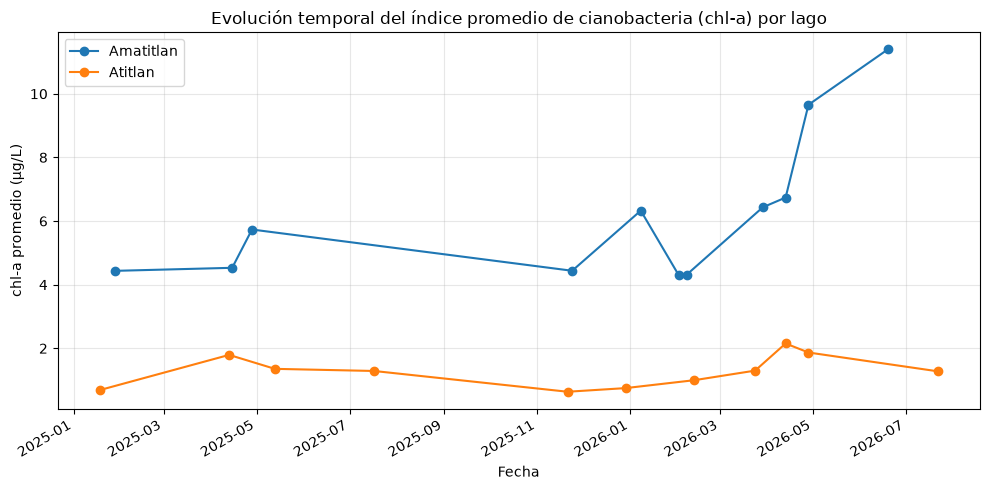

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for lago, grupo in df.groupby("lago"):
    ax.plot(grupo["fecha"], grupo["cyano_promedio"], marker="o", label=lago.capitalize())

ax.set_title("Evolución temporal del índice promedio de cianobacteria (chl-a) por lago")
ax.set_xlabel("Fecha")
ax.set_ylabel("chl-a promedio (µg/L)")
ax.legend()
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "serie_temporal_cyano.png", dpi=150)
plt.show()

In [4]:
# 4.3 Picos de floracion: fecha con el maximo cyano_promedio por lago
picos = df.loc[df.groupby("lago")["cyano_promedio"].idxmax(), ["lago", "fecha", "cyano_promedio", "pct_area_alta"]]
picos

,lago,fecha,cyano_promedio,pct_area_alta
10,amatitlan,2026-06-19,11.393601,6.436486
19,atitlan,2026-04-13,2.152002,0.000921


#### 4.4 Interpretación de los patrones temporales

*(Completar tras ejecutar con datos reales — describir si la proliferación aumenta, disminuye o fluctúa en cada lago, en qué fechas ocurren los picos identificados arriba, y qué factores estacionales o climáticos podrían explicarlos, p. ej. época seca/lluviosa, temperatura, escorrentía de nutrientes.)*